# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [3]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [4]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [8]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [126]:
# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=5000000.0) # CHANGE FOR EACH EXPERIMENT

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

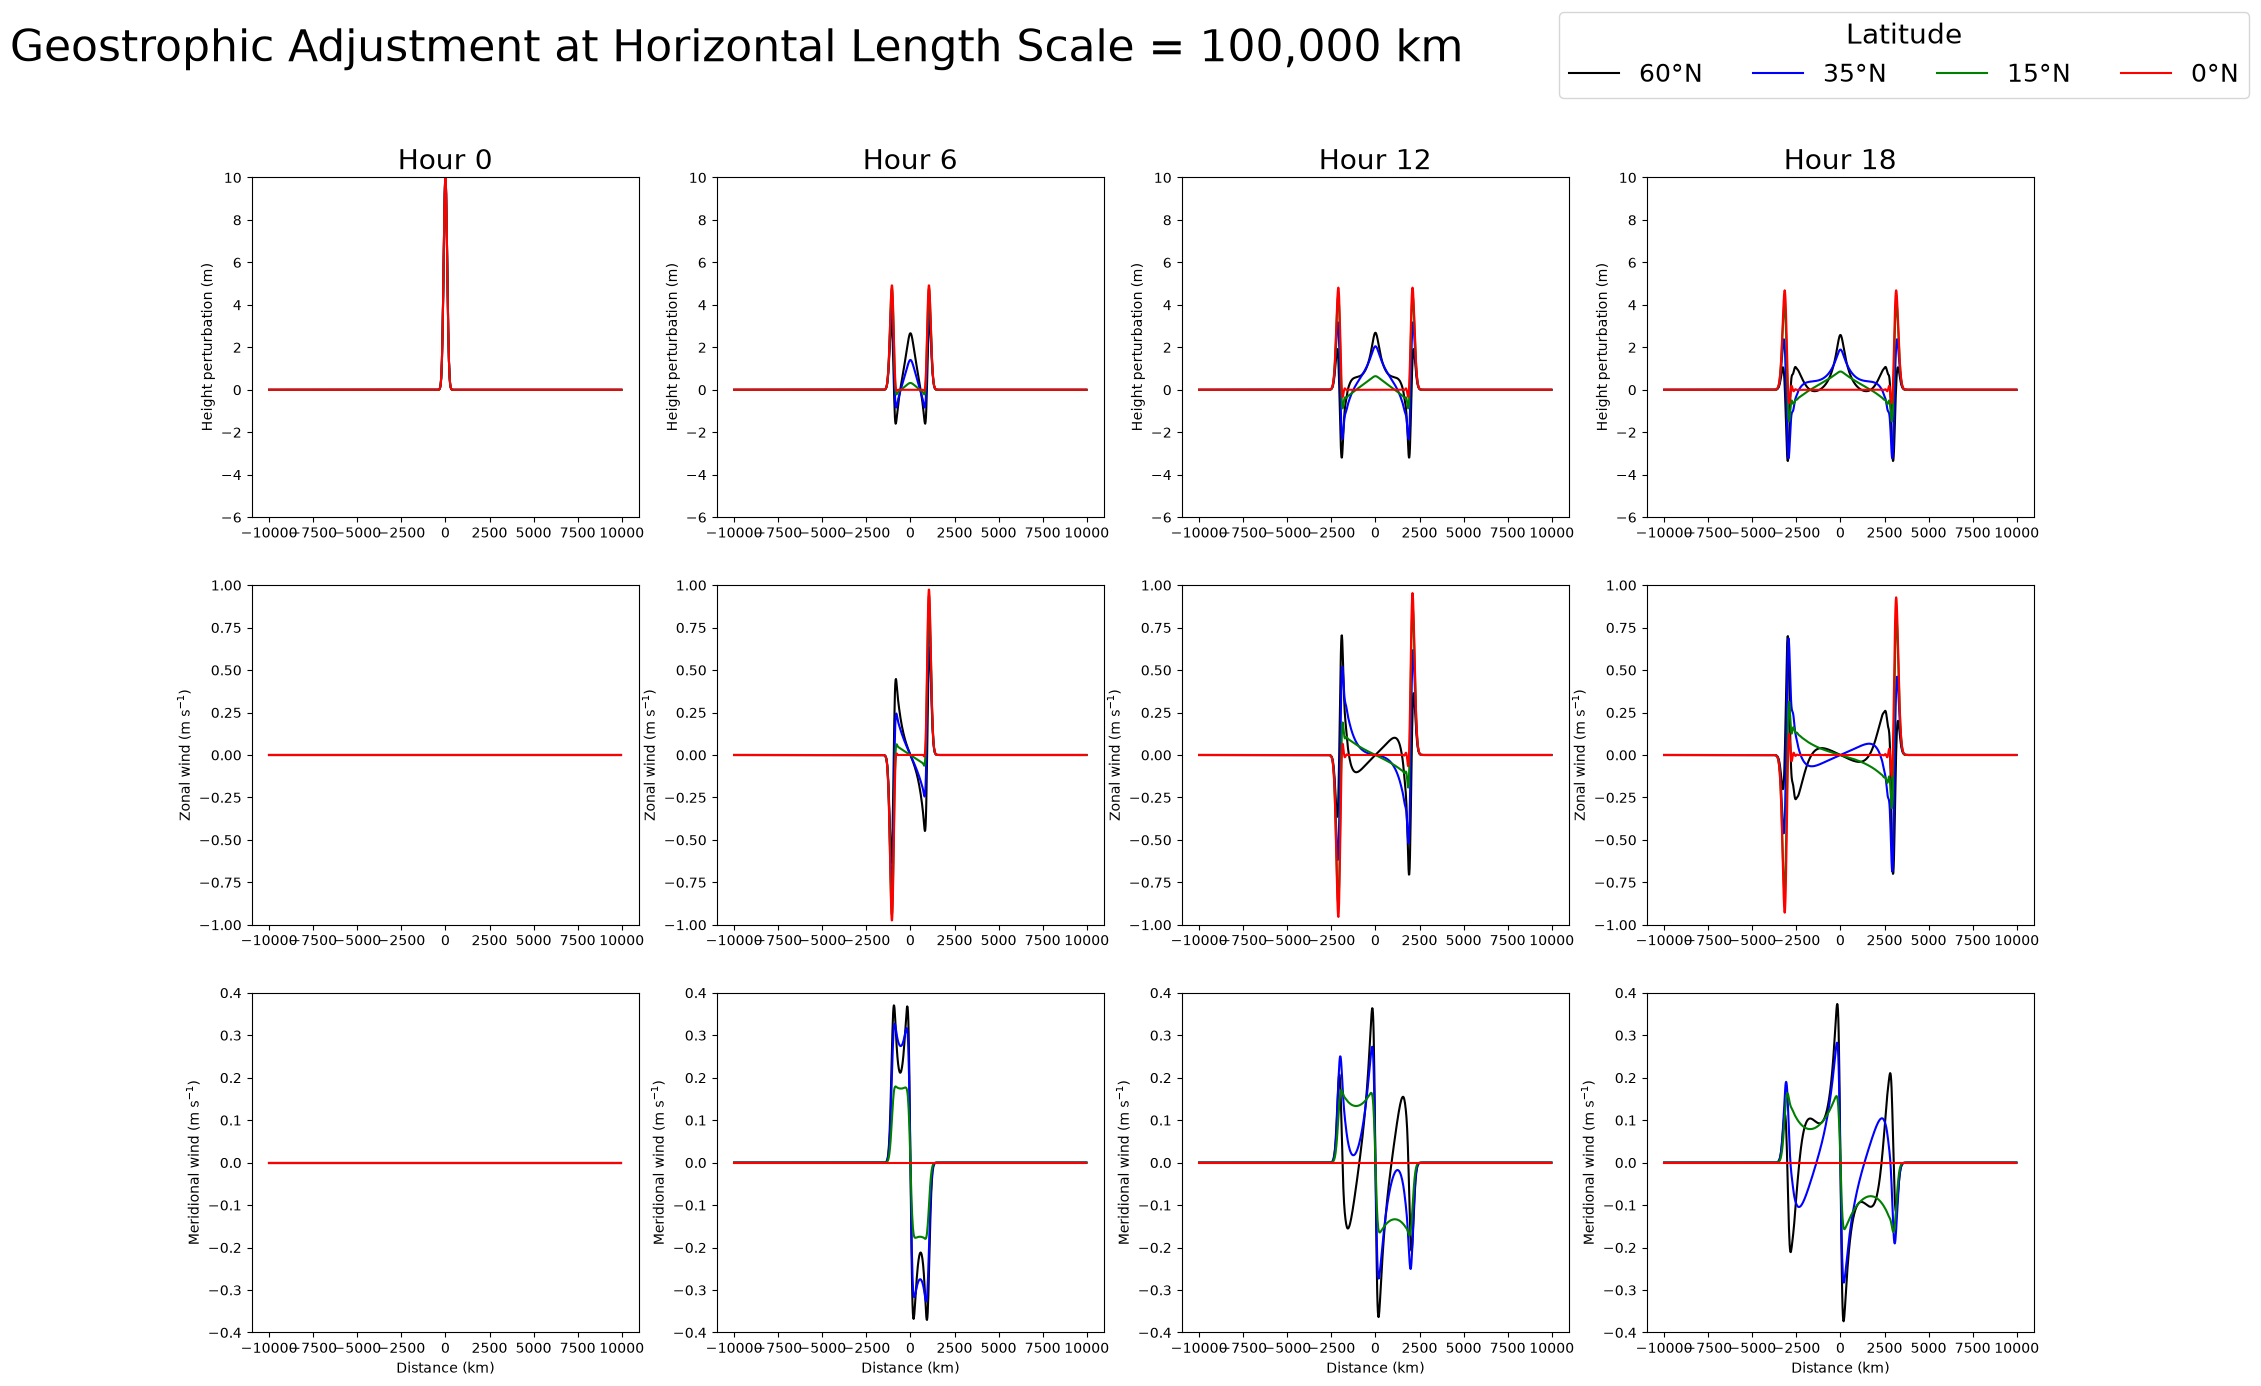

In [119]:
# PLOT FOR f = 0, 15, 35, and 60 AND L0 =  100000

# Establish the time indices 
plot_time_1 = 0 # Hour 0
plot_time_2 = 36 # Hour 6
plot_time_3 = 72 # Hour 12
plot_time_4 = 108 # Hour 18

run_60 = runs["60.0°N"]
variables_h_60 = run_60["h"]
variables_u_60 = run_60["u"]
variables_v_60 = run_60["v"]
x_km = run_60["x"] / 1000
times = run_60["time"] / 3600

run_35 = runs["35.0°N"]
variables_h_35 = run_35["h"]
variables_u_35 = run_35["u"]
variables_v_35 = run_35["v"]
x_km = run_35["x"] / 1000
times = run_35["time"] / 3600

run_15 = runs["15.0°N"]
variables_h_15 = run_15["h"]
variables_u_15 = run_15["u"]
variables_v_15 = run_15["v"]
x_km = run_15["x"] / 1000
times = run_15["time"] / 3600

run_0 = runs["0°N"]
variables_h_0 = run_0["h"]
variables_u_0 = run_0["u"]
variables_v_0 = run_0["v"]
x_km = run_0["x"] / 1000
times = run_0["time"] / 3600

fig, axes = plt.subplots(3, 4, figsize=(23, 15))

# Plotting for the height perturbation (h) at different times and latitudes
axes[0, 0].plot(x_km, variables_h_60[plot_time_1], color="black", label="60°N")
axes[0, 0].plot(x_km, variables_h_35[plot_time_1], color="blue", label="35°N")
axes[0, 0].plot(x_km, variables_h_15[plot_time_1], color="green", label="15°N")
axes[0, 0].plot(x_km, variables_h_0[plot_time_1], color="red", label="0°N")

axes[0, 1].plot(x_km, variables_h_60[plot_time_2], color="black")
axes[0, 1].plot(x_km, variables_h_35[plot_time_2], color="blue")
axes[0, 1].plot(x_km, variables_h_15[plot_time_2], color="green")
axes[0, 1].plot(x_km, variables_h_0[plot_time_2], color="red")

axes[0, 2].plot(x_km, variables_h_60[plot_time_3], color="black")
axes[0, 2].plot(x_km, variables_h_35[plot_time_3], color="blue")
axes[0, 2].plot(x_km, variables_h_15[plot_time_3], color="green")
axes[0, 2].plot(x_km, variables_h_0[plot_time_3], color="red")

axes[0, 3].plot(x_km, variables_h_60[plot_time_4], color="black")
axes[0, 3].plot(x_km, variables_h_35[plot_time_4], color="blue")
axes[0, 3].plot(x_km, variables_h_15[plot_time_4], color="green")
axes[0, 3].plot(x_km, variables_h_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[1, 0].plot(x_km, variables_u_60[plot_time_1], color="black")
axes[1, 0].plot(x_km, variables_u_35[plot_time_1], color="blue")
axes[1, 0].plot(x_km, variables_u_15[plot_time_1], color="green")
axes[1, 0].plot(x_km, variables_u_0[plot_time_1], color="red")

axes[1, 1].plot(x_km, variables_u_60[plot_time_2], color="black")
axes[1, 1].plot(x_km, variables_u_35[plot_time_2], color="blue")
axes[1, 1].plot(x_km, variables_u_15[plot_time_2], color="green")
axes[1, 1].plot(x_km, variables_u_0[plot_time_2], color="red")

axes[1, 2].plot(x_km, variables_u_60[plot_time_3], color="black")
axes[1, 2].plot(x_km, variables_u_35[plot_time_3], color="blue")
axes[1, 2].plot(x_km, variables_u_15[plot_time_3], color="green")
axes[1, 2].plot(x_km, variables_u_0[plot_time_3], color="red")

axes[1, 3].plot(x_km, variables_u_60[plot_time_4], color="black")
axes[1, 3].plot(x_km, variables_u_35[plot_time_4], color="blue")
axes[1, 3].plot(x_km, variables_u_15[plot_time_4], color="green")
axes[1, 3].plot(x_km, variables_u_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[2, 0].plot(x_km, variables_v_60[plot_time_1], color="black")
axes[2, 0].plot(x_km, variables_v_35[plot_time_1], color="blue")
axes[2, 0].plot(x_km, variables_v_15[plot_time_1], color="green")
axes[2, 0].plot(x_km, variables_v_0[plot_time_1], color="red")

axes[2, 1].plot(x_km, variables_v_60[plot_time_2], color="black")
axes[2, 1].plot(x_km, variables_v_35[plot_time_2], color="blue")
axes[2, 1].plot(x_km, variables_v_15[plot_time_2], color="green")
axes[2, 1].plot(x_km, variables_v_0[plot_time_2], color="red")

axes[2, 2].plot(x_km, variables_v_60[plot_time_3], color="black")
axes[2, 2].plot(x_km, variables_v_35[plot_time_3], color="blue")
axes[2, 2].plot(x_km, variables_v_15[plot_time_3], color="green")
axes[2, 2].plot(x_km, variables_v_0[plot_time_3], color="red")

axes[2, 3].plot(x_km, variables_v_60[plot_time_4], color="black")
axes[2, 3].plot(x_km, variables_v_35[plot_time_4], color="blue")
axes[2, 3].plot(x_km, variables_v_15[plot_time_4], color="green")
axes[2, 3].plot(x_km, variables_v_0[plot_time_4], color="red")

plt.suptitle(
    "Geostrophic Adjustment at Horizontal Length Scale = 100,000 km", x=0.02, ha="left", fontsize=32)

for ax in axes[0, :]:
    ax.set_ylim(-6, 10)      
    ax.set_ylabel("Height perturbation (m)")

for ax in axes[1, :]:
    ax.set_ylim(-1, 1)      
    ax.set_ylabel("Zonal wind (m s$^{-1}$)")

for ax in axes[2, :]:
    ax.set_ylim(-0.4, 0.4) 
    ax.set_ylabel("Meridional wind (m s$^{-1}$)")
    ax.set_xlabel("Distance (km)")

axes[0, 0].set_title("Hour 0", fontsize=20)
axes[0, 1].set_title("Hour 6", fontsize=20)
axes[0, 2].set_title("Hour 12", fontsize=20)
axes[0, 3].set_title("Hour 18", fontsize=20)

fig.legend(loc="upper right", ncol=4, fontsize=18, title="Latitude", title_fontsize=20)

plt.show()

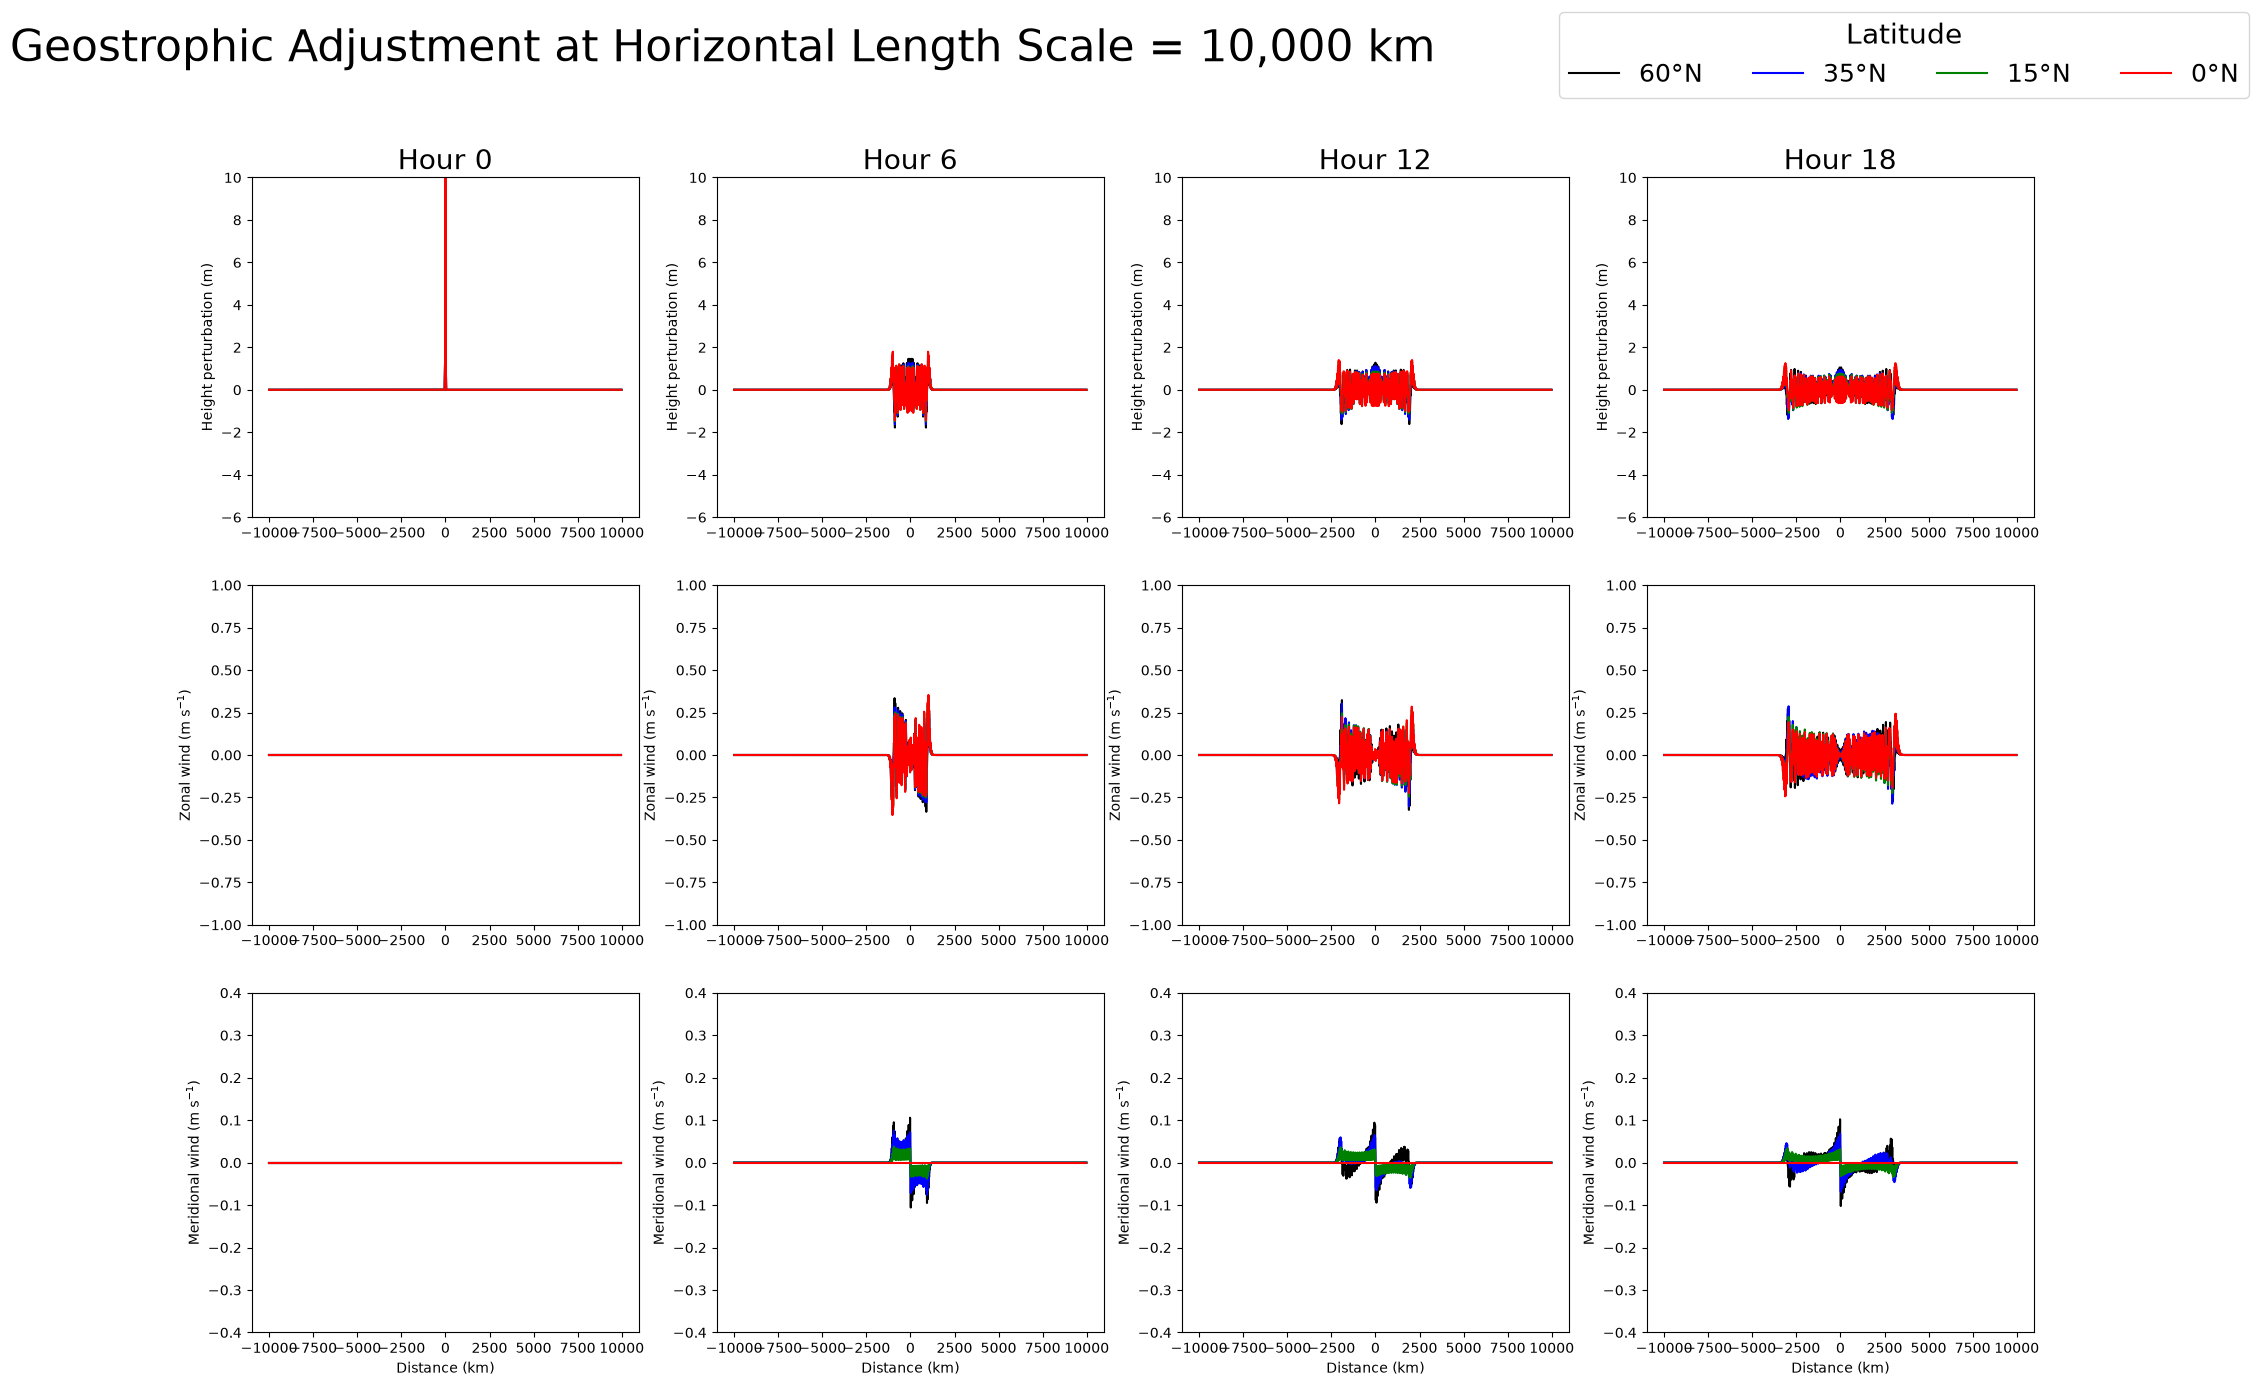

In [122]:
# PLOT FOR f = 0, 15, 35, and 60 AND L0 =  10000

# Establish the time indices 
plot_time_1 = 0 # Hour 0
plot_time_2 = 36 # Hour 6
plot_time_3 = 72 # Hour 12
plot_time_4 = 108 # Hour 18

run_60 = runs["60.0°N"]
variables_h_60 = run_60["h"]
variables_u_60 = run_60["u"]
variables_v_60 = run_60["v"]
x_km = run_60["x"] / 1000
times = run_60["time"] / 3600

run_35 = runs["35.0°N"]
variables_h_35 = run_35["h"]
variables_u_35 = run_35["u"]
variables_v_35 = run_35["v"]
x_km = run_35["x"] / 1000
times = run_35["time"] / 3600

run_15 = runs["15.0°N"]
variables_h_15 = run_15["h"]
variables_u_15 = run_15["u"]
variables_v_15 = run_15["v"]
x_km = run_15["x"] / 1000
times = run_15["time"] / 3600

run_0 = runs["0°N"]
variables_h_0 = run_0["h"]
variables_u_0 = run_0["u"]
variables_v_0 = run_0["v"]
x_km = run_0["x"] / 1000
times = run_0["time"] / 3600

fig, axes = plt.subplots(3, 4, figsize=(23, 15))

# Plotting for the height perturbation (h) at different times and latitudes
axes[0, 0].plot(x_km, variables_h_60[plot_time_1], color="black", label="60°N")
axes[0, 0].plot(x_km, variables_h_35[plot_time_1], color="blue", label="35°N")
axes[0, 0].plot(x_km, variables_h_15[plot_time_1], color="green", label="15°N")
axes[0, 0].plot(x_km, variables_h_0[plot_time_1], color="red", label="0°N")

axes[0, 1].plot(x_km, variables_h_60[plot_time_2], color="black")
axes[0, 1].plot(x_km, variables_h_35[plot_time_2], color="blue")
axes[0, 1].plot(x_km, variables_h_15[plot_time_2], color="green")
axes[0, 1].plot(x_km, variables_h_0[plot_time_2], color="red")

axes[0, 2].plot(x_km, variables_h_60[plot_time_3], color="black")
axes[0, 2].plot(x_km, variables_h_35[plot_time_3], color="blue")
axes[0, 2].plot(x_km, variables_h_15[plot_time_3], color="green")
axes[0, 2].plot(x_km, variables_h_0[plot_time_3], color="red")

axes[0, 3].plot(x_km, variables_h_60[plot_time_4], color="black")
axes[0, 3].plot(x_km, variables_h_35[plot_time_4], color="blue")
axes[0, 3].plot(x_km, variables_h_15[plot_time_4], color="green")
axes[0, 3].plot(x_km, variables_h_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[1, 0].plot(x_km, variables_u_60[plot_time_1], color="black")
axes[1, 0].plot(x_km, variables_u_35[plot_time_1], color="blue")
axes[1, 0].plot(x_km, variables_u_15[plot_time_1], color="green")
axes[1, 0].plot(x_km, variables_u_0[plot_time_1], color="red")

axes[1, 1].plot(x_km, variables_u_60[plot_time_2], color="black")
axes[1, 1].plot(x_km, variables_u_35[plot_time_2], color="blue")
axes[1, 1].plot(x_km, variables_u_15[plot_time_2], color="green")
axes[1, 1].plot(x_km, variables_u_0[plot_time_2], color="red")

axes[1, 2].plot(x_km, variables_u_60[plot_time_3], color="black")
axes[1, 2].plot(x_km, variables_u_35[plot_time_3], color="blue")
axes[1, 2].plot(x_km, variables_u_15[plot_time_3], color="green")
axes[1, 2].plot(x_km, variables_u_0[plot_time_3], color="red")

axes[1, 3].plot(x_km, variables_u_60[plot_time_4], color="black")
axes[1, 3].plot(x_km, variables_u_35[plot_time_4], color="blue")
axes[1, 3].plot(x_km, variables_u_15[plot_time_4], color="green")
axes[1, 3].plot(x_km, variables_u_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[2, 0].plot(x_km, variables_v_60[plot_time_1], color="black")
axes[2, 0].plot(x_km, variables_v_35[plot_time_1], color="blue")
axes[2, 0].plot(x_km, variables_v_15[plot_time_1], color="green")
axes[2, 0].plot(x_km, variables_v_0[plot_time_1], color="red")

axes[2, 1].plot(x_km, variables_v_60[plot_time_2], color="black")
axes[2, 1].plot(x_km, variables_v_35[plot_time_2], color="blue")
axes[2, 1].plot(x_km, variables_v_15[plot_time_2], color="green")
axes[2, 1].plot(x_km, variables_v_0[plot_time_2], color="red")

axes[2, 2].plot(x_km, variables_v_60[plot_time_3], color="black")
axes[2, 2].plot(x_km, variables_v_35[plot_time_3], color="blue")
axes[2, 2].plot(x_km, variables_v_15[plot_time_3], color="green")
axes[2, 2].plot(x_km, variables_v_0[plot_time_3], color="red")

axes[2, 3].plot(x_km, variables_v_60[plot_time_4], color="black")
axes[2, 3].plot(x_km, variables_v_35[plot_time_4], color="blue")
axes[2, 3].plot(x_km, variables_v_15[plot_time_4], color="green")
axes[2, 3].plot(x_km, variables_v_0[plot_time_4], color="red")

plt.suptitle(
    "Geostrophic Adjustment at Horizontal Length Scale = 10,000 km", x=0.02, ha="left", fontsize=32)

for ax in axes[0, :]:
    ax.set_ylim(-6, 10)      
    ax.set_ylabel("Height perturbation (m)")

for ax in axes[1, :]:
    ax.set_ylim(-1, 1)      
    ax.set_ylabel("Zonal wind (m s$^{-1}$)")

for ax in axes[2, :]:
    ax.set_ylim(-0.4, 0.4) 
    ax.set_ylabel("Meridional wind (m s$^{-1}$)")
    ax.set_xlabel("Distance (km)")

axes[0, 0].set_title("Hour 0", fontsize=20)
axes[0, 1].set_title("Hour 6", fontsize=20)
axes[0, 2].set_title("Hour 12", fontsize=20)
axes[0, 3].set_title("Hour 18", fontsize=20)

fig.legend(loc="upper right", ncol=4, fontsize=18, title="Latitude", title_fontsize=20)

plt.show()

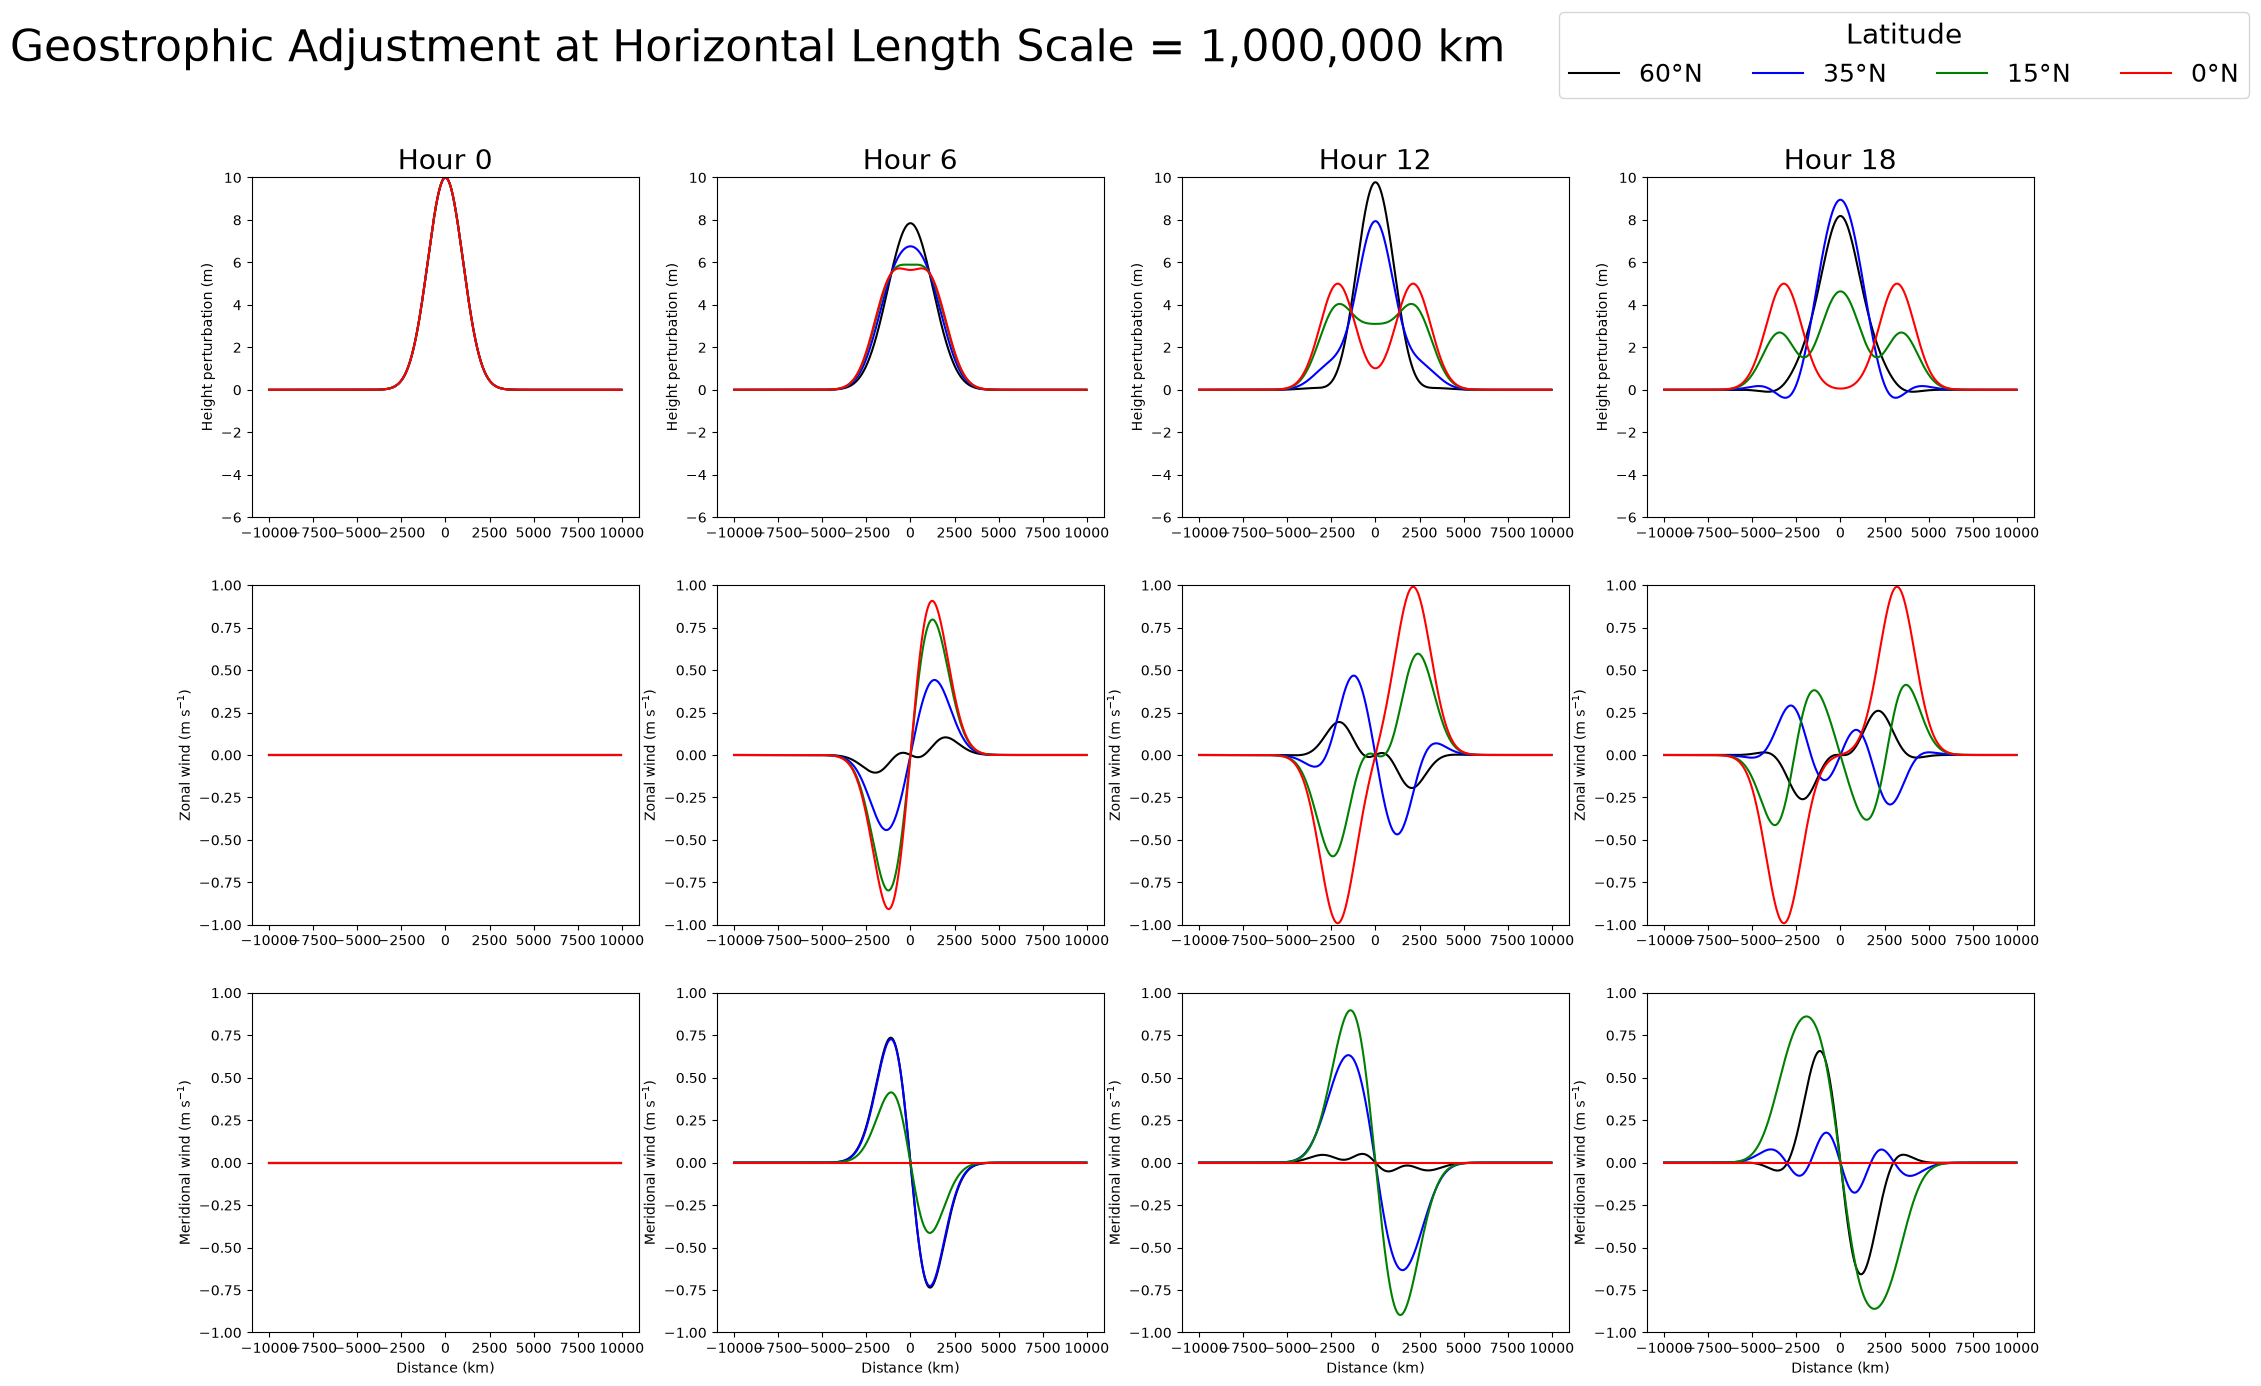

In [124]:
# PLOT FOR f = 0, 15, 35, and 60 AND L0 =  10000000

# Establish the time indices 
plot_time_1 = 0 # Hour 0
plot_time_2 = 36 # Hour 6
plot_time_3 = 72 # Hour 12
plot_time_4 = 108 # Hour 18

run_60 = runs["60.0°N"]
variables_h_60 = run_60["h"]
variables_u_60 = run_60["u"]
variables_v_60 = run_60["v"]
x_km = run_60["x"] / 1000
times = run_60["time"] / 3600

run_35 = runs["35.0°N"]
variables_h_35 = run_35["h"]
variables_u_35 = run_35["u"]
variables_v_35 = run_35["v"]
x_km = run_35["x"] / 1000
times = run_35["time"] / 3600

run_15 = runs["15.0°N"]
variables_h_15 = run_15["h"]
variables_u_15 = run_15["u"]
variables_v_15 = run_15["v"]
x_km = run_15["x"] / 1000
times = run_15["time"] / 3600

run_0 = runs["0°N"]
variables_h_0 = run_0["h"]
variables_u_0 = run_0["u"]
variables_v_0 = run_0["v"]
x_km = run_0["x"] / 1000
times = run_0["time"] / 3600

fig, axes = plt.subplots(3, 4, figsize=(23, 15))

# Plotting for the height perturbation (h) at different times and latitudes
axes[0, 0].plot(x_km, variables_h_60[plot_time_1], color="black", label="60°N")
axes[0, 0].plot(x_km, variables_h_35[plot_time_1], color="blue", label="35°N")
axes[0, 0].plot(x_km, variables_h_15[plot_time_1], color="green", label="15°N")
axes[0, 0].plot(x_km, variables_h_0[plot_time_1], color="red", label="0°N")

axes[0, 1].plot(x_km, variables_h_60[plot_time_2], color="black")
axes[0, 1].plot(x_km, variables_h_35[plot_time_2], color="blue")
axes[0, 1].plot(x_km, variables_h_15[plot_time_2], color="green")
axes[0, 1].plot(x_km, variables_h_0[plot_time_2], color="red")

axes[0, 2].plot(x_km, variables_h_60[plot_time_3], color="black")
axes[0, 2].plot(x_km, variables_h_35[plot_time_3], color="blue")
axes[0, 2].plot(x_km, variables_h_15[plot_time_3], color="green")
axes[0, 2].plot(x_km, variables_h_0[plot_time_3], color="red")

axes[0, 3].plot(x_km, variables_h_60[plot_time_4], color="black")
axes[0, 3].plot(x_km, variables_h_35[plot_time_4], color="blue")
axes[0, 3].plot(x_km, variables_h_15[plot_time_4], color="green")
axes[0, 3].plot(x_km, variables_h_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[1, 0].plot(x_km, variables_u_60[plot_time_1], color="black")
axes[1, 0].plot(x_km, variables_u_35[plot_time_1], color="blue")
axes[1, 0].plot(x_km, variables_u_15[plot_time_1], color="green")
axes[1, 0].plot(x_km, variables_u_0[plot_time_1], color="red")

axes[1, 1].plot(x_km, variables_u_60[plot_time_2], color="black")
axes[1, 1].plot(x_km, variables_u_35[plot_time_2], color="blue")
axes[1, 1].plot(x_km, variables_u_15[plot_time_2], color="green")
axes[1, 1].plot(x_km, variables_u_0[plot_time_2], color="red")

axes[1, 2].plot(x_km, variables_u_60[plot_time_3], color="black")
axes[1, 2].plot(x_km, variables_u_35[plot_time_3], color="blue")
axes[1, 2].plot(x_km, variables_u_15[plot_time_3], color="green")
axes[1, 2].plot(x_km, variables_u_0[plot_time_3], color="red")

axes[1, 3].plot(x_km, variables_u_60[plot_time_4], color="black")
axes[1, 3].plot(x_km, variables_u_35[plot_time_4], color="blue")
axes[1, 3].plot(x_km, variables_u_15[plot_time_4], color="green")
axes[1, 3].plot(x_km, variables_u_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[2, 0].plot(x_km, variables_v_60[plot_time_1], color="black")
axes[2, 0].plot(x_km, variables_v_35[plot_time_1], color="blue")
axes[2, 0].plot(x_km, variables_v_15[plot_time_1], color="green")
axes[2, 0].plot(x_km, variables_v_0[plot_time_1], color="red")

axes[2, 1].plot(x_km, variables_v_60[plot_time_2], color="black")
axes[2, 1].plot(x_km, variables_v_35[plot_time_2], color="blue")
axes[2, 1].plot(x_km, variables_v_15[plot_time_2], color="green")
axes[2, 1].plot(x_km, variables_v_0[plot_time_2], color="red")

axes[2, 2].plot(x_km, variables_v_60[plot_time_3], color="black")
axes[2, 2].plot(x_km, variables_v_35[plot_time_3], color="blue")
axes[2, 2].plot(x_km, variables_v_15[plot_time_3], color="green")
axes[2, 2].plot(x_km, variables_v_0[plot_time_3], color="red")

axes[2, 3].plot(x_km, variables_v_60[plot_time_4], color="black")
axes[2, 3].plot(x_km, variables_v_35[plot_time_4], color="blue")
axes[2, 3].plot(x_km, variables_v_15[plot_time_4], color="green")
axes[2, 3].plot(x_km, variables_v_0[plot_time_4], color="red")

plt.suptitle(
    "Geostrophic Adjustment at Horizontal Length Scale = 1,000,000 km", x=0.02, ha="left", fontsize=32)

for ax in axes[0, :]:
    ax.set_ylim(-6, 10)      
    ax.set_ylabel("Height perturbation (m)")

for ax in axes[1, :]:
    ax.set_ylim(-1, 1)      
    ax.set_ylabel("Zonal wind (m s$^{-1}$)")

for ax in axes[2, :]:
    ax.set_ylim(-1, 1) 
    ax.set_ylabel("Meridional wind (m s$^{-1}$)")
    ax.set_xlabel("Distance (km)")

axes[0, 0].set_title("Hour 0", fontsize=20)
axes[0, 1].set_title("Hour 6", fontsize=20)
axes[0, 2].set_title("Hour 12", fontsize=20)
axes[0, 3].set_title("Hour 18", fontsize=20)

fig.legend(loc="upper right", ncol=4, fontsize=18, title="Latitude", title_fontsize=20)

plt.show()

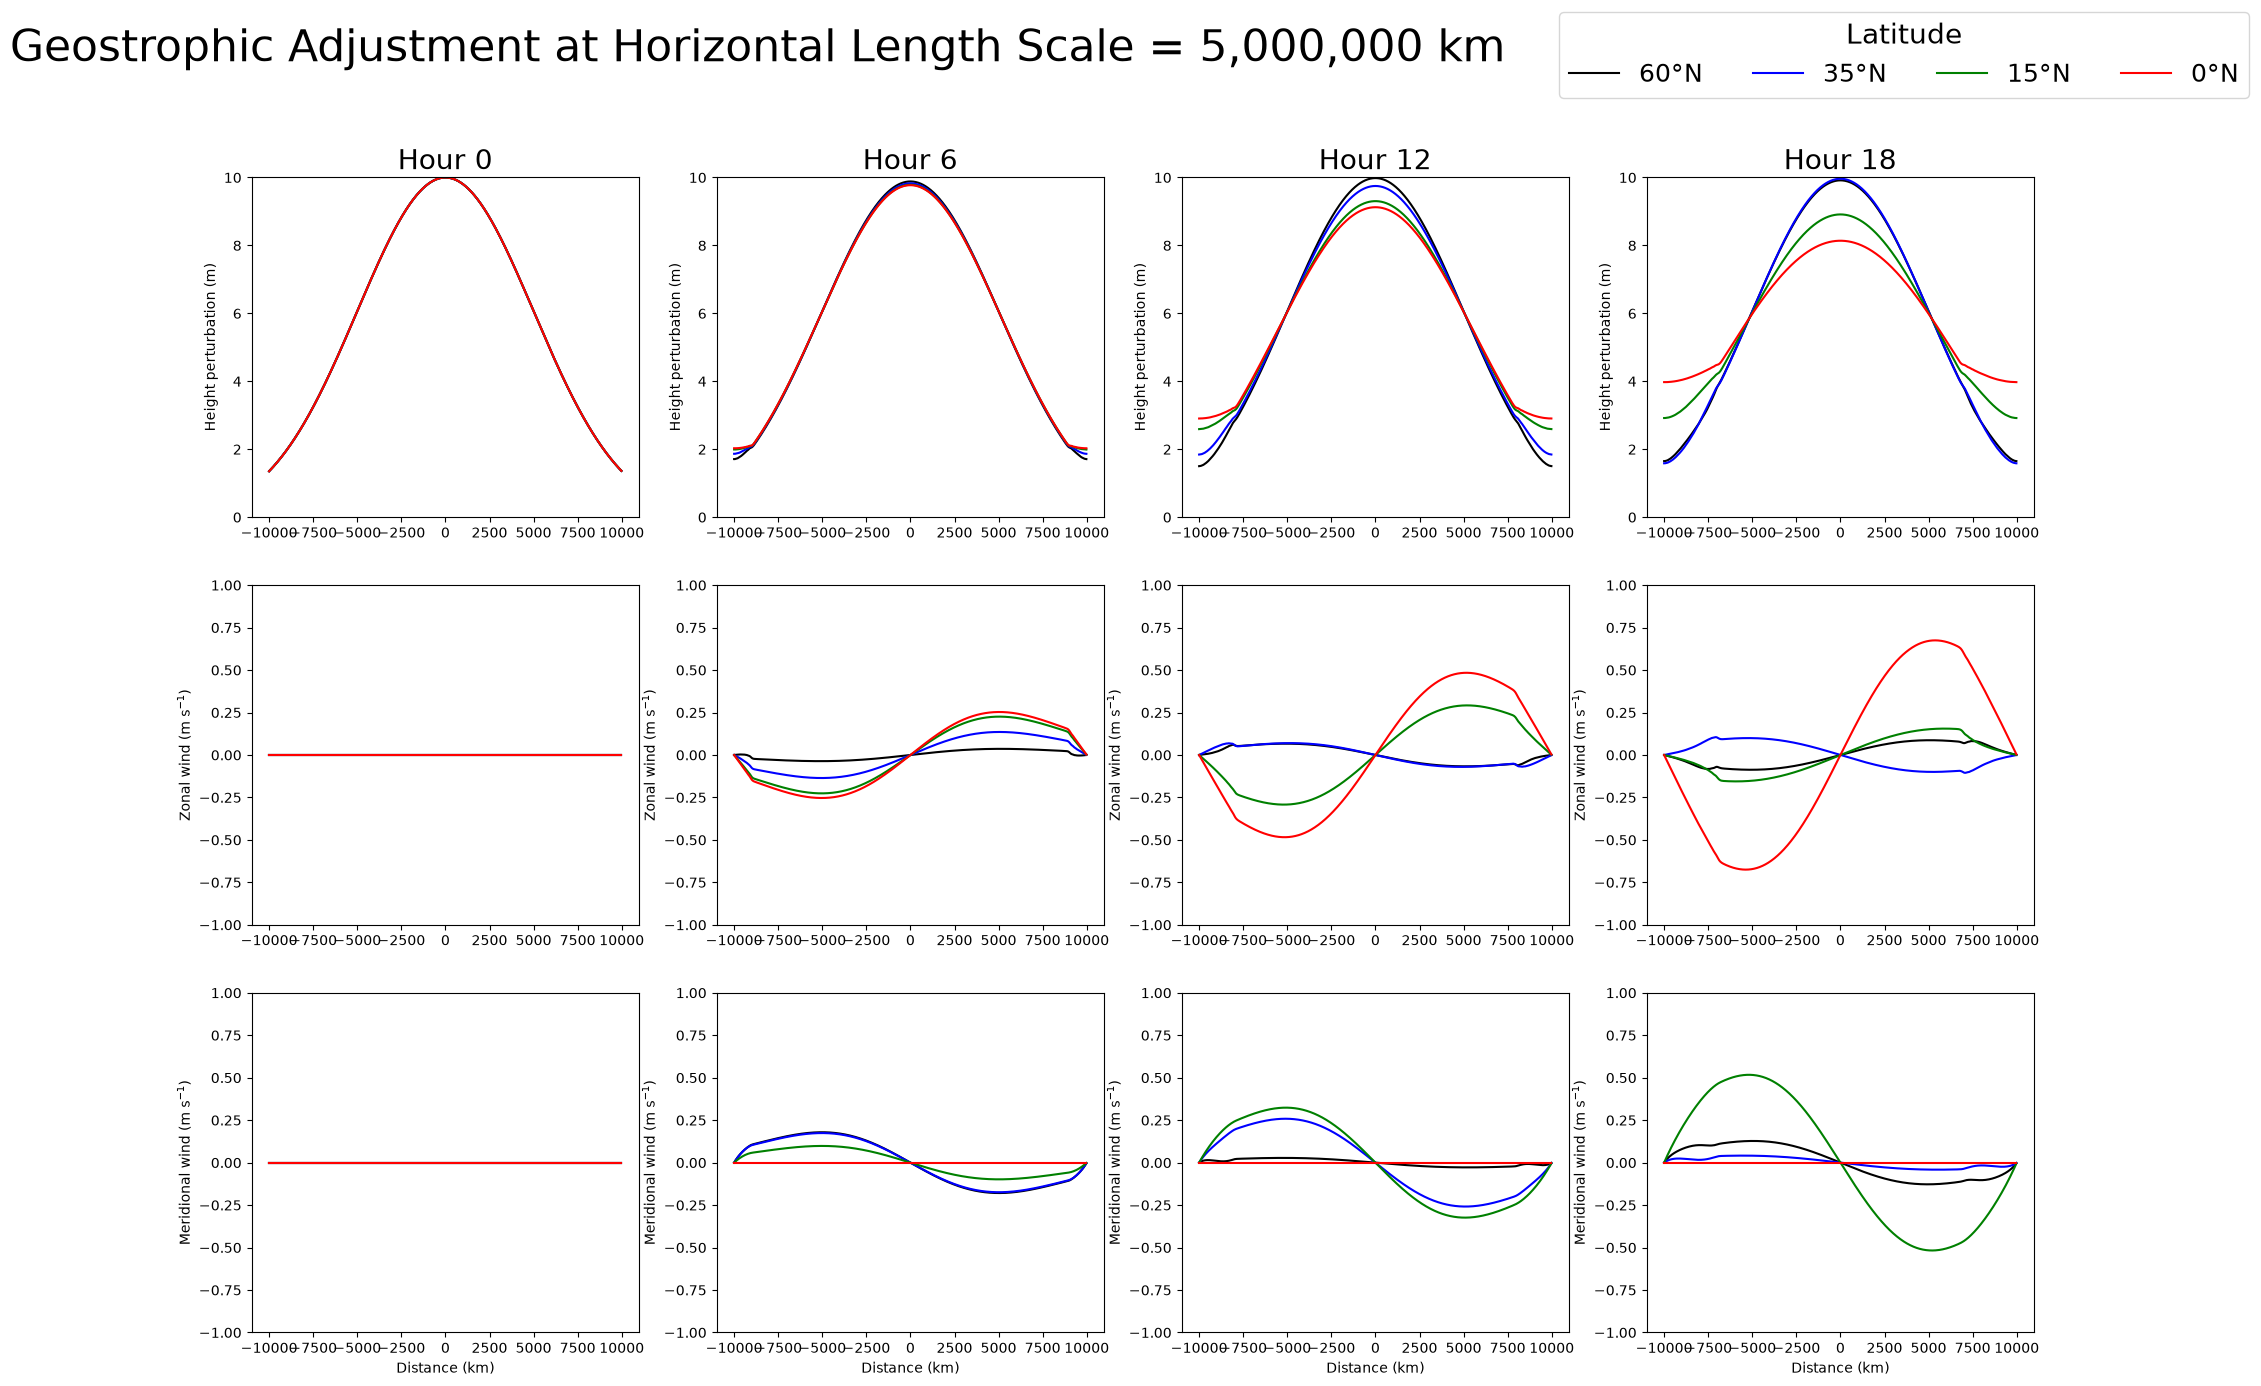

In [129]:
# PLOT FOR f = 0, 15, 35, and 60 AND L0 = 5000000

# Establish the time indices 
plot_time_1 = 0 # Hour 0
plot_time_2 = 36 # Hour 6
plot_time_3 = 72 # Hour 12
plot_time_4 = 108 # Hour 18

run_60 = runs["60.0°N"]
variables_h_60 = run_60["h"]
variables_u_60 = run_60["u"]
variables_v_60 = run_60["v"]
x_km = run_60["x"] / 1000
times = run_60["time"] / 3600

run_35 = runs["35.0°N"]
variables_h_35 = run_35["h"]
variables_u_35 = run_35["u"]
variables_v_35 = run_35["v"]
x_km = run_35["x"] / 1000
times = run_35["time"] / 3600

run_15 = runs["15.0°N"]
variables_h_15 = run_15["h"]
variables_u_15 = run_15["u"]
variables_v_15 = run_15["v"]
x_km = run_15["x"] / 1000
times = run_15["time"] / 3600

run_0 = runs["0°N"]
variables_h_0 = run_0["h"]
variables_u_0 = run_0["u"]
variables_v_0 = run_0["v"]
x_km = run_0["x"] / 1000
times = run_0["time"] / 3600

fig, axes = plt.subplots(3, 4, figsize=(23, 15))

# Plotting for the height perturbation (h) at different times and latitudes
axes[0, 0].plot(x_km, variables_h_60[plot_time_1], color="black", label="60°N")
axes[0, 0].plot(x_km, variables_h_35[plot_time_1], color="blue", label="35°N")
axes[0, 0].plot(x_km, variables_h_15[plot_time_1], color="green", label="15°N")
axes[0, 0].plot(x_km, variables_h_0[plot_time_1], color="red", label="0°N")

axes[0, 1].plot(x_km, variables_h_60[plot_time_2], color="black")
axes[0, 1].plot(x_km, variables_h_35[plot_time_2], color="blue")
axes[0, 1].plot(x_km, variables_h_15[plot_time_2], color="green")
axes[0, 1].plot(x_km, variables_h_0[plot_time_2], color="red")

axes[0, 2].plot(x_km, variables_h_60[plot_time_3], color="black")
axes[0, 2].plot(x_km, variables_h_35[plot_time_3], color="blue")
axes[0, 2].plot(x_km, variables_h_15[plot_time_3], color="green")
axes[0, 2].plot(x_km, variables_h_0[plot_time_3], color="red")

axes[0, 3].plot(x_km, variables_h_60[plot_time_4], color="black")
axes[0, 3].plot(x_km, variables_h_35[plot_time_4], color="blue")
axes[0, 3].plot(x_km, variables_h_15[plot_time_4], color="green")
axes[0, 3].plot(x_km, variables_h_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[1, 0].plot(x_km, variables_u_60[plot_time_1], color="black")
axes[1, 0].plot(x_km, variables_u_35[plot_time_1], color="blue")
axes[1, 0].plot(x_km, variables_u_15[plot_time_1], color="green")
axes[1, 0].plot(x_km, variables_u_0[plot_time_1], color="red")

axes[1, 1].plot(x_km, variables_u_60[plot_time_2], color="black")
axes[1, 1].plot(x_km, variables_u_35[plot_time_2], color="blue")
axes[1, 1].plot(x_km, variables_u_15[plot_time_2], color="green")
axes[1, 1].plot(x_km, variables_u_0[plot_time_2], color="red")

axes[1, 2].plot(x_km, variables_u_60[plot_time_3], color="black")
axes[1, 2].plot(x_km, variables_u_35[plot_time_3], color="blue")
axes[1, 2].plot(x_km, variables_u_15[plot_time_3], color="green")
axes[1, 2].plot(x_km, variables_u_0[plot_time_3], color="red")

axes[1, 3].plot(x_km, variables_u_60[plot_time_4], color="black")
axes[1, 3].plot(x_km, variables_u_35[plot_time_4], color="blue")
axes[1, 3].plot(x_km, variables_u_15[plot_time_4], color="green")
axes[1, 3].plot(x_km, variables_u_0[plot_time_4], color="red")

# Plotting for the zonal wind (u) at different times and latitudes
axes[2, 0].plot(x_km, variables_v_60[plot_time_1], color="black")
axes[2, 0].plot(x_km, variables_v_35[plot_time_1], color="blue")
axes[2, 0].plot(x_km, variables_v_15[plot_time_1], color="green")
axes[2, 0].plot(x_km, variables_v_0[plot_time_1], color="red")

axes[2, 1].plot(x_km, variables_v_60[plot_time_2], color="black")
axes[2, 1].plot(x_km, variables_v_35[plot_time_2], color="blue")
axes[2, 1].plot(x_km, variables_v_15[plot_time_2], color="green")
axes[2, 1].plot(x_km, variables_v_0[plot_time_2], color="red")

axes[2, 2].plot(x_km, variables_v_60[plot_time_3], color="black")
axes[2, 2].plot(x_km, variables_v_35[plot_time_3], color="blue")
axes[2, 2].plot(x_km, variables_v_15[plot_time_3], color="green")
axes[2, 2].plot(x_km, variables_v_0[plot_time_3], color="red")

axes[2, 3].plot(x_km, variables_v_60[plot_time_4], color="black")
axes[2, 3].plot(x_km, variables_v_35[plot_time_4], color="blue")
axes[2, 3].plot(x_km, variables_v_15[plot_time_4], color="green")
axes[2, 3].plot(x_km, variables_v_0[plot_time_4], color="red")

plt.suptitle(
    "Geostrophic Adjustment at Horizontal Length Scale = 5,000,000 km", x=0.02, ha="left", fontsize=32)

for ax in axes[0, :]:
    ax.set_ylim(0, 10)      
    ax.set_ylabel("Height perturbation (m)")

for ax in axes[1, :]:
    ax.set_ylim(-1, 1)      
    ax.set_ylabel("Zonal wind (m s$^{-1}$)")

for ax in axes[2, :]:
    ax.set_ylim(-1, 1) 
    ax.set_ylabel("Meridional wind (m s$^{-1}$)")
    ax.set_xlabel("Distance (km)")

axes[0, 0].set_title("Hour 0", fontsize=20)
axes[0, 1].set_title("Hour 6", fontsize=20)
axes[0, 2].set_title("Hour 12", fontsize=20)
axes[0, 3].set_title("Hour 18", fontsize=20)

fig.legend(loc="upper right", ncol=4, fontsize=18, title="Latitude", title_fontsize=20)

plt.show()

## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [103]:
H = 250.0
g = 9.81 

for f in [0, 15, 35, 60]:
    for L_0 in [10000, 100000, 1000000, 5000000]:

        f0 = coriolis_parameter(f)

        LD = np.sqrt(g * H) / np.abs(f0)
        BU = (LD / L_0) ** 2

        if f == 0:
            print(f"IF f: {f}°N AND L_0: {L_0} km; LD: NaN, BU: NaN, Ro: NaN, U: NaN")
        else:
            run_dgn = runs[f"{f}.0°N"]

            u_wind = run_dgn["u"]
            v_wind = run_dgn["v"]
            U = np.sqrt(np.max(u_wind)**2 + np.max(v_wind)**2)

            Ro = U / (np.abs(f0) * L_0)
            print(f"IF f: {f}°N AND L_0: {L_0} km; LD: {LD:.4f}, BU: {BU:.4f}, Ro: {Ro:.4f}, U: {U:.4f}")
  

IF f: 0°N AND L_0: 10000 km; LD: NaN, BU: NaN, Ro: NaN, U: NaN
IF f: 0°N AND L_0: 100000 km; LD: NaN, BU: NaN, Ro: NaN, U: NaN
IF f: 0°N AND L_0: 1000000 km; LD: NaN, BU: NaN, Ro: NaN, U: NaN
IF f: 0°N AND L_0: 5000000 km; LD: NaN, BU: NaN, Ro: NaN, U: NaN
IF f: 15°N AND L_0: 10000 km; LD: 1311972.4612, BU: 17212.7174, Ro: 2.6521, U: 1.0011
IF f: 15°N AND L_0: 100000 km; LD: 1311972.4612, BU: 172.1272, Ro: 0.2652, U: 1.0011
IF f: 15°N AND L_0: 1000000 km; LD: 1311972.4612, BU: 1.7213, Ro: 0.0265, U: 1.0011
IF f: 15°N AND L_0: 5000000 km; LD: 1311972.4612, BU: 0.0689, Ro: 0.0053, U: 1.0011
IF f: 35°N AND L_0: 10000 km; LD: 592010.8256, BU: 3504.7682, Ro: 1.2475, U: 1.0435
IF f: 35°N AND L_0: 100000 km; LD: 592010.8256, BU: 35.0477, Ro: 0.1247, U: 1.0435
IF f: 35°N AND L_0: 1000000 km; LD: 592010.8256, BU: 0.3505, Ro: 0.0125, U: 1.0435
IF f: 35°N AND L_0: 5000000 km; LD: 592010.8256, BU: 0.0140, Ro: 0.0025, U: 1.0435
IF f: 60°N AND L_0: 10000 km; LD: 392094.1096, BU: 1537.3779, Ro: 0.863

/var/folders/6x/fmdc6b017_50pmwjyvbwk68c0000gv/T/ipykernel_47080/2235675730.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  LD = np.sqrt(g * H) / np.abs(f0)


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

For a rotating experiment, it appears that the initial height perturbation is what results in the geostrophic adjustment process initiating and motion occuring. Across all four experiments, the initial height perturbation is set to be 10 meters, and the zonal and meridional components of the wind are zero. We also know that geostrophic balance is a balance between atmospheric pressure and the coriolis force. If there is some change in the pressure, which is represented in this experiment by a height perturbation (or a deviation from the mean atmospheric height), we know that the wind field must respond as a result.  We see this across all rendiations of this experiment because the wind field responds shortly after the initial perturbation, as we see both the zonal and meridional components of the wind begin to change from their initial state of 0 ms-1. 

In the time proceeding t=0, the initial pressure perturbation begins to move back toward some intial/resting state. In an attempt to recover the geostropic balance, the wind field response from their inital state. Across all of the experiments ran, we see that by time = 6, the intial height perturanation has decreased in height, while the zonal component of the wind increases in the positive x direction and decreases in the negative x direction directly adjacent to the initial location of the height perturbation. In t=12 and t=18, we see the zonal wind field grow in amplitude, as well as translate away from the inital location of the height perturbtation. For the meridional wind field, we see a nearly inverted response, in which the wind decreases in the position x direction and increases in the negative x direction. This is the case for all latitudes expect for the equator, where the meridional wind remains nearly 0 despite the height perturbation. The ampltidue of the meridional wind for all other latitudes also increases with time and moves away from the intial locaiton of the initial height perturbation. 

As for the height peturbation itself, we begin to see the ampltidue decreases at time = 6. However, for some horizonal length scales, we actually begin to see the perturbation begin to oscillate, so that the peturbation is never completley zero across the entire horzional. The maximums in the height peturbation are closely spatially aligned with the minimums in the zonal wind field and the maximums in the meridional wind field, and vice versa in some instances. In addition, between time = 12 and time = 18, the location of the height peturbation maximums and minimums appears to become more closely aligned with the zonal and meridional wind maximums and minimums, but it is hard to say with certainity that thsi is happening from a visual inspection.

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

For latitude 0°N, the initial height perturbation at 

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?

One thing which I understood better after completing this lab was how the zonal and the meridional wind components behave differently during the geostrophic adustment process depending on latitude. I understood the differences in coriolis parameter with latitude before this experiment as well as how the components of the wind change with latitude, but for some reason, I do not think that I understood how drastic the zonal component of the wind would change so drastically over time at the equator while the meridional component of the wind would remain near constant, desptie the height peturbation. Overall, I think I could have came to this same conclusion knowing the trends in coriolis force with latitude, but this lab helped me understand this concept through the use of the visuals. 

As far as programming is concerning, I think a major takeaway for me after this lab is that creating a simple model is definatley less complicated that it initially seems, and is much easier to comprehend than I thought it would be. It was also a good exercise for finding creative ways to visualize several multi-dimensional data across time, and under various different conditions. I think just simply thinking about the types of plots I wanted to make to understand the data and the model was one of the most challenging (and also enjoyable) aspects of this lab. 